---
#**Single asperity simulations**
---


In [15]:
import sys
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import scipy #(find peaks)
from scipy.signal import find_peaks
from datetime import datetime
import itertools
import json
from google.colab import drive
#import plotly as plt
drive.mount('/content/drive')

!chmod +x /content/drive/MyDrive/Tesi/qdyn/qdyn
path_wrapper = '/content/drive/MyDrive/Tesi/qdyn'
sys.path.append(path_wrapper)
sys.path.append('/content/drive/MyDrive/Tesi/qdyn/utils/post_processing')

from pyqdyn import *
from plot_functions import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
#Funzioni di set-up
---

In [16]:
#Set-up cartella per i dati
cartella_output = "/content/drive/MyDrive/Tesi/Grafici"
os.makedirs(cartella_output, exist_ok=True)

In [17]:
def timeseries(ot, ot_vmax, tmin=None, tmax=None, figsize=(10, 8)):
    #Assign simulation tmin and tmax if not specified
    if tmin is None:
        tmin = ot['t'].min()
    if tmax is None:
        tmax = ot['t'].max()

    #Check that tmin and tmax are within the limits
    if tmin < ot['t'].min():
        print('tmin is smaller than min t of simulation')
        return
    if tmax > ot['t'].max():
        print('tmax is larger than max t of simulation')
        return

    #Filter data based on the chosen time window
    ot_sample      = ot[(ot['t'] >= tmin) & (ot['t'] <= tmax)]
    ot_vmax_sample = ot_vmax[(ot_vmax['t'] >= tmin) & (ot_vmax['t'] <= tmax)]

    #Create the 4 plots
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=figsize)

    #Plot 1: Shear stress (tau) + find_peaks
    tau_vals = ot_sample["tau"].values
    t_vals   = ot_sample["t"].values

    peaks_idx, _ = find_peaks(tau_vals, prominence=1e3)

    axes[0].plot(t_vals, tau_vals, color="crimson")
    axes[0].plot(t_vals[peaks_idx], tau_vals[peaks_idx],
                 "kv", ms=6, label=f"{len(peaks_idx)} picchi trovati")
    axes[0].set_ylabel("tau [Pa]")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend(fontsize=9)

    #Stampa i tempi dei picchi
    print(f"\n--- PICCHI TAU: {len(peaks_idx)} ---")
    for i, idx in enumerate(peaks_idx):
        print(f"  Picco {i+1:>3}: t = {t_vals[idx]:.4f} s,  tau = {tau_vals[idx]:.3e} Pa")

    #Plot 2: State variable (theta)
    axes[1].plot(ot_sample["t"], ot_sample["theta"], color="forestgreen")
    axes[1].set_ylabel("state [s]")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    #Plot 3: Normal stress (sigma)
    axes[2].plot(ot_sample["t"], ot_sample["sigma"], color="darkorange")
    axes[2].set_ylabel("sigma [Pa]")
    axes[2].grid(True, linestyle=":", alpha=0.6)

    #Plot 4: Maximum velocity (v)
    axes[3].plot(ot_vmax_sample["t"], ot_vmax_sample["v"], color="navy")
    axes[3].set_ylabel("max v [m/s]")
    axes[3].set_xlabel("time [s]")
    axes[3].set_yscale("log")
    axes[3].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [18]:
%matplotlib inline
def slip_profile(ox, warm_up=0, orientation="horizontal", figsize=(10, 8), save_path=None):
    """
    Plots the spatio-temporal evolution of slip rates as a contour map.

    Arguments:
        ox (DataFrame/dict): Output spatial data from the simulation, containing
                             at least the columns/keys 'x' (position), 't' (time),
                             'slip' (cumulative slip), and 'v' (slip velocity).
        warm_up (float, optional): Time in seconds to skip at the beginning of
                                   the simulation to ignore transient startup effects.
                                   Defaults to 0.
        orientation (str, optional): The layout of the plot.
                                     "horizontal" plots slip (y-axis) vs position (x-axis).
                                     "vertical" plots depth (y-axis) vs slip (x-axis).
                                     Defaults to "horizontal".
        figsize (tuple, optional): Dimensions of the figure (width, height).
                                   Defaults to (10, 8).
    """
    x_unique = ox["x"].unique()
    sort_inds = np.argsort(x_unique)
    x_unique = x_unique[sort_inds]
    t_vals = np.sort(ox["t"].unique())

    if warm_up > t_vals.max():
        print("Warm-up time > simulation time!")
        return

    ind_warmup = np.where(t_vals >= warm_up)[0][0]

    Nx = len(x_unique)
    Nt = len(t_vals) - 1

    slice_idx = np.s_[Nx * ind_warmup:Nx * Nt]
    data_shape = (Nt - ind_warmup, Nx)
    x = ox["x"][slice_idx].values.reshape(data_shape)[:, sort_inds]
    slip = ox["slip"][slice_idx].values.reshape(data_shape)[:, sort_inds]
    v = ox["v"][slice_idx].values.reshape(data_shape)[:, sort_inds]

    slip -= slip[0]
    t = t_vals[ind_warmup:-1]
    t -= t[0]

    fig = plt.figure(figsize=figsize)

    if orientation == "horizontal":
        CS = plt.contourf(x, slip, np.log10(v), levels=200, cmap="magma")
        plt.xlabel("position [m]")
        plt.ylabel("slip [m]")
        CB = plt.colorbar(CS, orientation="horizontal")
        CB.ax.set_title("slip rate [m/s]")
    elif orientation == "vertical":
        x -= x.min()
        CS = plt.contourf(slip, x * 1e-3, np.log10(v), levels=200, cmap="magma")
        plt.ylabel("depth [km]")
        plt.xlabel("slip [m]")
        plt.gca().invert_yaxis()
        CB = plt.colorbar(CS, orientation="horizontal")
        CB.ax.set_title("slip rate [m/s]")
    else:
        print("Keyword 'orientation=%s' not recognised" % orientation)
        plt.close()
        return
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()

In [19]:
def plot_spatiotemporal_slip_rate(ox, warm_up=0, save_path=None):
    """
    Spatio-temporal map of the slip rate using the correct reshape for QDYN.

    Arguments:
        ox (DataFrame/dict): Output spatial data from the simulation, containing
                             at least the columns/keys 'x' (position), 't' (time),
                             and 'v' (slip velocity).
        warm_up (float, optional): Time in seconds to skip at the beginning of
                                   the simulation to ignore transient startup effects.
                                   Defaults to 0.
    """
    #1. Find unique values and sorting indices
    from matplotlib.colors import LogNorm
    x_unique = ox["x"].unique()
    sort_inds = np.argsort(x_unique)
    x_sorted = x_unique[sort_inds]
    t_vals = np.sort(ox["t"].unique())

    if warm_up > t_vals.max():
        print("Warm-up time > simulation time!")
        return

    ind_warmup = np.where(t_vals >= warm_up)[0][0]

    Nx = len(x_unique)
    Nt = len(t_vals) - 1

    #2. Reshape data from 1D to 2D matrix (Time x Space)
    slice_idx = np.s_[Nx * ind_warmup : Nx * Nt]
    data_shape = (Nt - ind_warmup, Nx)

    #Extract and resize velocity, applying spatial sort
    v_2d = ox["v"].iloc[slice_idx].values.reshape(data_shape)[:, sort_inds]

    #Prepare X and Y axes for time and space
    t = t_vals[ind_warmup:-1]
    #Convert x_sorted to centimeters, starting from 0
    x_cm = (x_sorted - x_sorted.min()) * 100

    #Convert v_2d to µm/s
    v_ums = v_2d * 1e6
    #Avoid absolute zero to prevent errors with the logarithmic scale
    #v_ums = np.clip(v_ums, a_min=1e-5, a_max=None)

    #3. Create grid
    T, X = np.meshgrid(t, x_cm)

    #4. Plotting
    fig = plt.figure(figsize=(8, 7))

    #pcolormesh is perfect for this type of waterfall diagram
    mappa = plt.pcolormesh(X, T, np.log10(v_ums.T),
                           cmap="magma", shading="auto")

    #Invert the Y-axis to have 0 at the top
    plt.gca().invert_yaxis()

    #Labels and titles
    plt.ylabel("Time [s]", fontsize=14)
    plt.xlabel("Position along the fault [cm]", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    #Logarithmic scale colorbar
    cbar = plt.colorbar(mappa, pad=0.02)
    cbar.set_label("Slip rate [µm/s]", fontsize=14) # Note: Plotted values are actually log10(µm/s)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()

---
#Funzione di salvataggio
---

In [20]:
def salva_evento(p, b, Dc, sigma_n, tmin, tmax, n_evento, n_sim, oggi, cartella_sim):
    #Cartella evento -> Cartella simulazione
    nome_evento  = f"Evento_{n_evento:03d}"
    cartella_ev  = os.path.join(cartella_sim, nome_evento)
    os.makedirs(cartella_ev, exist_ok=True)

    #Slicing dei grafici
    ot      = p.ot[0]
    ot_vmax = p.ot_vmax
    ox      = p.ox

    ot_slice     = ot[(ot['t'] >= tmin) & (ot['t'] <= tmax)]
    vmax_slice   = ot_vmax[(ot_vmax['t'] >= tmin) & (ot_vmax['t'] <= tmax)]
    ox_slice     = ox[(ox['t'] >= tmin) & (ox['t'] <= tmax)]

    #Metadati
    metadati = {
        "simulazione_n" : n_sim,
        "evento_n"      : n_evento,
        "data"          : oggi,
        "tmin_s"        : tmin,
        "tmax_s"        : tmax,
        "b"             : b,
        "Dc_m"          : Dc,
        "sigma_n_Pa"    : sigma_n,
        "TMAX"          : p.set_dict["TMAX"],
        "V_PL"          : p.set_dict["V_PL"],
        "MU"            : p.set_dict["MU"],
        "N"             : p.set_dict["N"],
        "L"             : p.set_dict["L"],
    }
    metadati_str = json.dumps(metadati)

    #Salva .npz
    np.savez_compressed(
        os.path.join(cartella_ev, "dati.npz"),
        metadati  = np.array(metadati_str),
        ot_t      = ot_slice['t'].values,
        ot_tau    = ot_slice['tau'].values,
        ot_theta  = ot_slice['theta'].values,
        ot_sigma  = ot_slice['sigma'].values,
        ot_vmax_t = vmax_slice['t'].values,
        ot_vmax_v = vmax_slice['v'].values,
        ox_x      = ox_slice['x'].values,
        ox_t      = ox_slice['t'].values,
        ox_v      = ox_slice['v'].values,
        ox_slip   = ox_slice['slip'].values,
    )

    #Timeseries tagliata
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8))
    axes[0].plot(ot_slice["t"], ot_slice["tau"],       color="crimson");     axes[0].set_ylabel("tau [Pa]");    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[1].plot(ot_slice["t"], ot_slice["theta"],     color="forestgreen"); axes[1].set_ylabel("state [s]");   axes[1].grid(True, linestyle=":", alpha=0.6)
    axes[2].plot(ot_slice["t"], ot_slice["sigma"],     color="darkorange");  axes[2].set_ylabel("sigma [Pa]");  axes[2].grid(True, linestyle=":", alpha=0.6)
    axes[3].plot(vmax_slice["t"], vmax_slice["v"],     color="navy");        axes[3].set_ylabel("max v [m/s]"); axes[3].set_xlabel("time [s]"); axes[3].set_yscale("log"); axes[3].grid(True, linestyle=":", alpha=0.6)
    fig.suptitle(f"Sim {n_sim} — Evento {n_evento} — t=[{tmin:.3f}, {tmax:.3f}]s\nb={b}  Dc={Dc*1e6:.1f}µm  σn={sigma_n/1e6:.1f}MPa", fontsize=10)
    plt.tight_layout()
    fig.savefig(os.path.join(cartella_ev, "timeseries.png"), dpi=150)
    plt.close(fig)

    #Slip_profile tagliato
    slip_profile(ox_slice, save_path=os.path.join(cartella_ev, "slip_profile.png"))

    #Spatiotemporal tagliato
    plot_spatiotemporal_slip_rate(ox_slice, save_path=os.path.join(cartella_ev, "spatiotemporal.png"))

    print(f"  → Evento {n_evento:03d}: t=[{tmin:.4f}, {tmax:.4f}]s salvato")

In [21]:
def salva_simulazione(p, b, Dc, sigma_n):

    oggi = datetime.now().strftime("%Y%m%d")

    #ind_peaks su tau PRIMA di creare qualsiasi cartella
    tau_vals  = p.ot[0]['tau'].values
    t_vals    = p.ot[0]['t'].values
    peaks_idx, _ = find_peaks(tau_vals, prominence=1e3)

    if len(peaks_idx) == 0:
        print("  ⚠ Nessun picco trovato: nessun file salvato.")
        print("    Abbassa 'prominence' in find_peaks oppure verifica i parametri della simulazione.")
        return None

    #Contatore
    file_contatore = os.path.join(cartella_output, f"contatore_{oggi}.txt")
    if os.path.exists(file_contatore):
        with open(file_contatore, "r") as f:
            n_sim = int(f.read().strip()) + 1
    else:
        n_sim = 1
    with open(file_contatore, "w") as f:
        f.write(str(n_sim))

    #Cartella simulazione
    nome_sim     = f"Simulazione_{n_sim}_{oggi}"
    cartella_sim = os.path.join(cartella_output, nome_sim)
    os.makedirs(cartella_sim, exist_ok=True)
    print(f"\nSimulazione {n_sim} — salvataggio in: {cartella_sim}")

    if len(peaks_idx) == 1:
        tmin = t_vals[0]
        tmax = t_vals[peaks_idx[0]]
        print(f"  1 picco trovato → 1 evento da salvare (t=[{tmin:.4f}, {tmax:.4f}]s)")
        salva_evento(p, b, Dc, sigma_n, tmin, tmax,
                     n_evento=1, n_sim=n_sim, oggi=oggi, cartella_sim=cartella_sim)
        print(f"\n✓ Simulazione {n_sim} completata: 1 evento salvato in '{nome_sim}'")
        return cartella_sim

    print(f"  {len(peaks_idx)} picchi trovati → {len(peaks_idx) - 1} eventi da salvare")

    t_bordi = [t_vals[0]] + list(t_vals[peaks_idx]) + [t_vals[-1]]

    for i in range(len(t_bordi) - 1):
        tmin = t_bordi[i]
        tmax = t_bordi[i + 1]
        salva_evento(p, b, Dc, sigma_n, tmin, tmax,
                     n_evento=i + 1, n_sim=n_sim, oggi=oggi, cartella_sim=cartella_sim)

    n_eventi = len(t_bordi) - 1
    print(f"\n✓ Simulazione {n_sim} completata: {n_eventi} eventi salvati in '{nome_sim}'")
    return cartella_sim

---
#Produzione grafici e iterazioni
---

In [22]:
def parametri(b, Dc, sigma_n):
  p = qdyn()
  L = 0.75                    #75 cm fault
  Lasp = 0.5                  #50 cm asperity
  cab_ratio = 0.9             #1 - (a/b)
  N = 512                     #must be a 2**N
  set_dict = p.set_dict

  #Simulation parameters
  set_dict["MESHDIM"] = 1
  set_dict["FINITE"] = 0
  set_dict["TMAX"] = 20      #Spostiamo da 100 a 20
  set_dict["V_PL"] = 10e-6    #Loading velocity

  set_dict["NTOUT_LOG"] = 10
  set_dict["NTOUT_OT"] = 1
  set_dict["NTOUT_OX"] = 5
  set_dict["NXOUT_OX"] = 2

  set_dict["MU"] = 2e9
  set_dict["W"] = 0.04
  set_dict["SIGMA"] = sigma_n #50e6 standard, può andare da 3 a 10 MPa
  set_dict["ACC"] = 1e-7
  set_dict["SOLVER"] = 2
  set_dict["N"] = N
  set_dict["L"] = L
  set_dict["IC"] = N // 2

  #RSF parameters (Optimized for 75cm)
  #set_dict["SET_DICT_RSF"]["A"] = 0.03
  set_dict["SET_DICT_RSF"]["B"] = b #0.011, 0.012, 0.013
  set_dict["SET_DICT_RSF"]["DC"] = Dc #da 1 a 15 μm

  #Pertubation
  set_dict["SET_DICT_RSF"]["V_SS"] = set_dict["V_PL"]
  set_dict["SET_DICT_RSF"]["V_0"] = set_dict["V_PL"] * 0.01
  set_dict["SET_DICT_RSF"]["TH_0"] = set_dict["SET_DICT_RSF"]["DC"] / set_dict["V_PL"]

  #Calculation of real physical lengths
  Lb = set_dict["MU"] * set_dict["SET_DICT_RSF"]["DC"] / (set_dict["SET_DICT_RSF"]["B"] * set_dict["SIGMA"])
  Lc = Lb / cab_ratio
  h = L / N

  print("\n--- PHYSICAL AND NUMERICAL CHECK ---")
  print(f"Asperity Size (Lasp) = {Lasp:.4f} m")
  print(f"Nucleation Length (Lc) = {Lc:.4f} m")
  print(f"Lasp / Lc = {Lasp/Lc:.2f} (Should be > 1 for Stick-Slip)")
  print(f"Mesh Resolution (Lb / h) = {Lb/h:.0f} points (Should be > 10)")

  #Setup of the Heterogeneous Mesh
  p.settings(set_dict)
  p.render_mesh()

  x = np.linspace(-L/2, L/2, N, dtype=float)

  #Asperity profile creation (Velocity-Weakening in the center)
  A_array = set_dict["SET_DICT_RSF"]["B"] * (1 + cab_ratio * (1 - 2 * np.exp(-(2 * x / Lasp) ** 6)))

  #Pass all arrays to QDYN to force reading them
  p.mesh_dict["A"] = A_array
  p.mesh_dict["B"] = np.ones(N) * set_dict["SET_DICT_RSF"]["B"]
  p.mesh_dict["DC"] = np.ones(N) * set_dict["SET_DICT_RSF"]["DC"]

  p.set_dict["VERBOSE"] = 0
  p.write_input()
  p.run()
  print("p.run() eseguito")
  p.read_output()
  print("p.read_output() eseguito")

  #Grafici
  timeseries(p.ot[0], p.ot_vmax)
  slip_profile(p.ox)
  plot_spatiotemporal_slip_rate(p.ox)

  #Salvataggio
  salva_simulazione(p, b, Dc, sigma_n)


--- PHYSICAL AND NUMERICAL CHECK ---
Asperity Size (Lasp) = 0.5000 m
Nucleation Length (Lc) = 0.0101 m
Lasp / Lc = 49.50 (Should be > 1 for Stick-Slip)
Mesh Resolution (Lb / h) = 6 points (Should be > 10)
p.run() eseguito
p.read_output() eseguito

--- PICCHI TAU: 2 ---
  Picco   1: t = 0.2222 s,  tau = 1.221e+07 Pa
  Picco   2: t = 1.8631 s,  tau = 1.262e+07 Pa


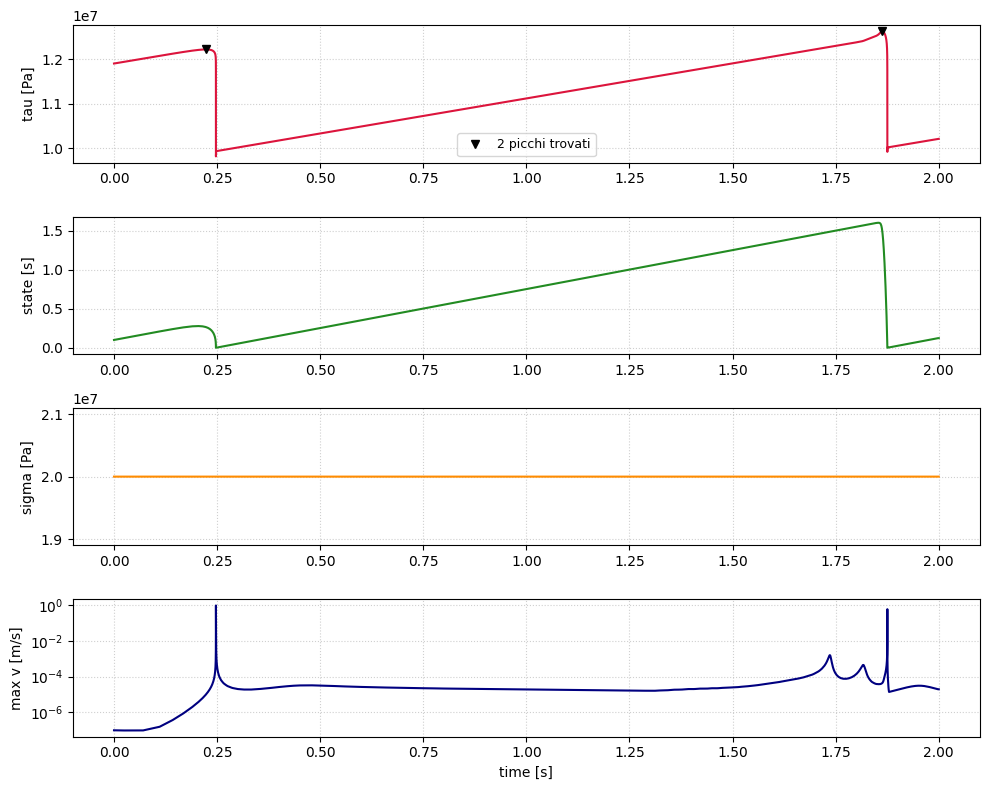

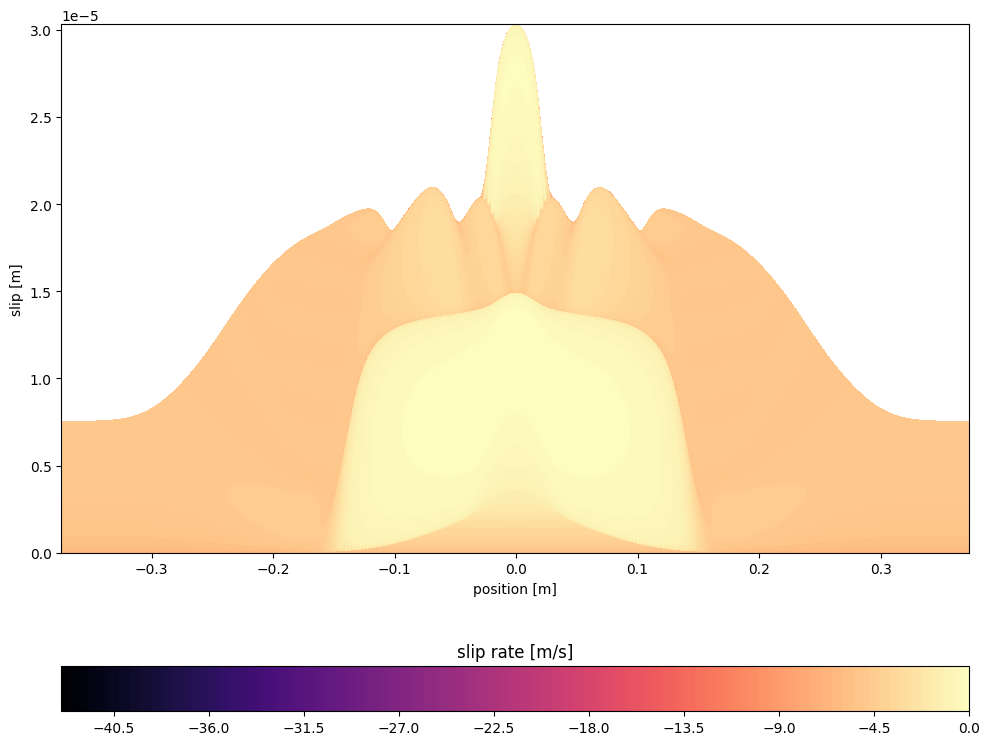

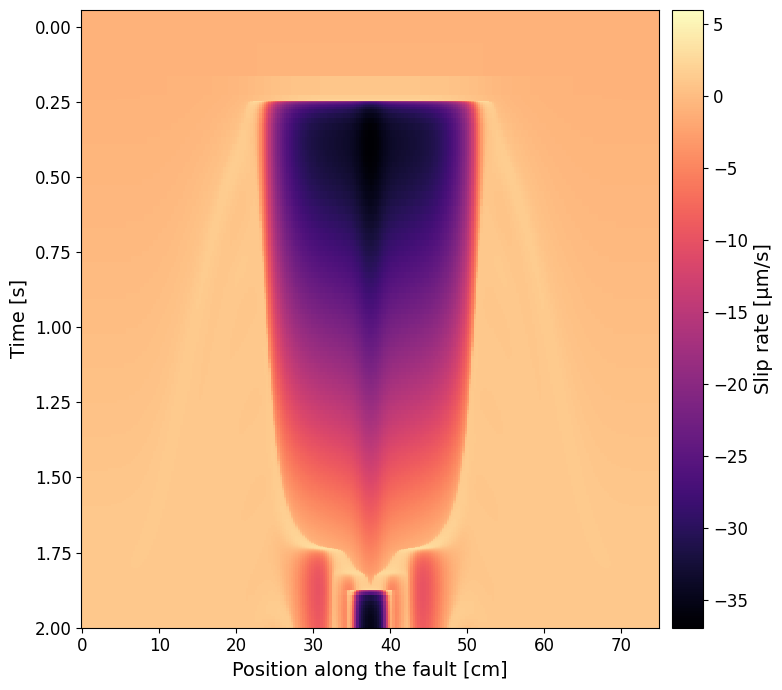


Simulazione 4 — salvataggio in: /content/drive/MyDrive/Tesi/Grafici/Simulazione_4_20260519
  2 picchi trovati → 1 eventi da salvare


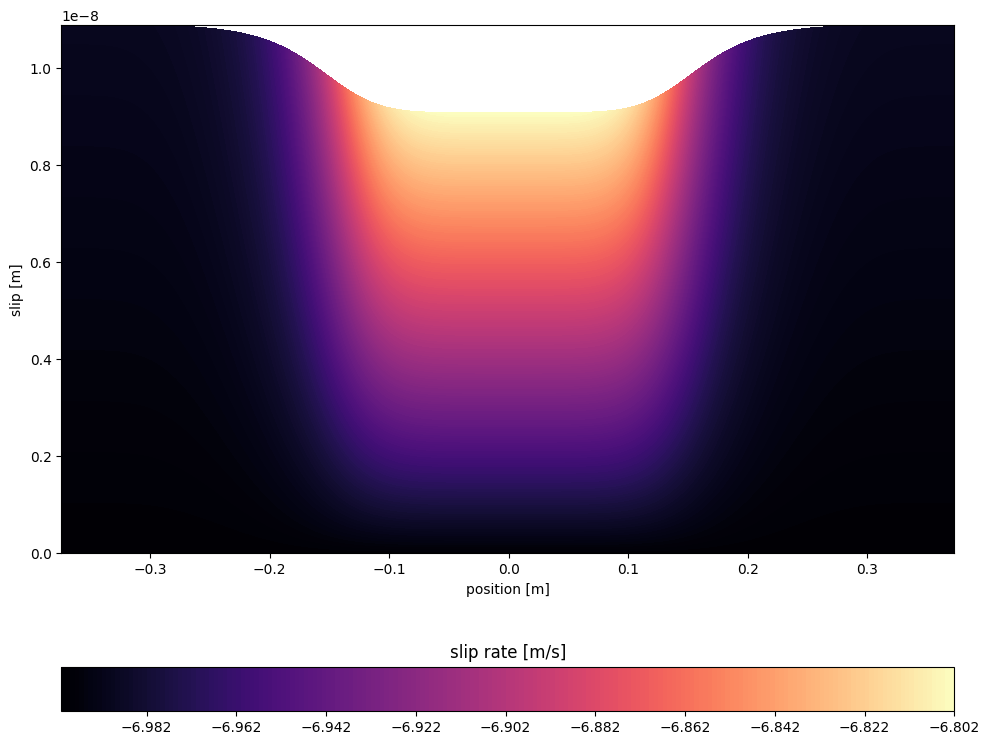

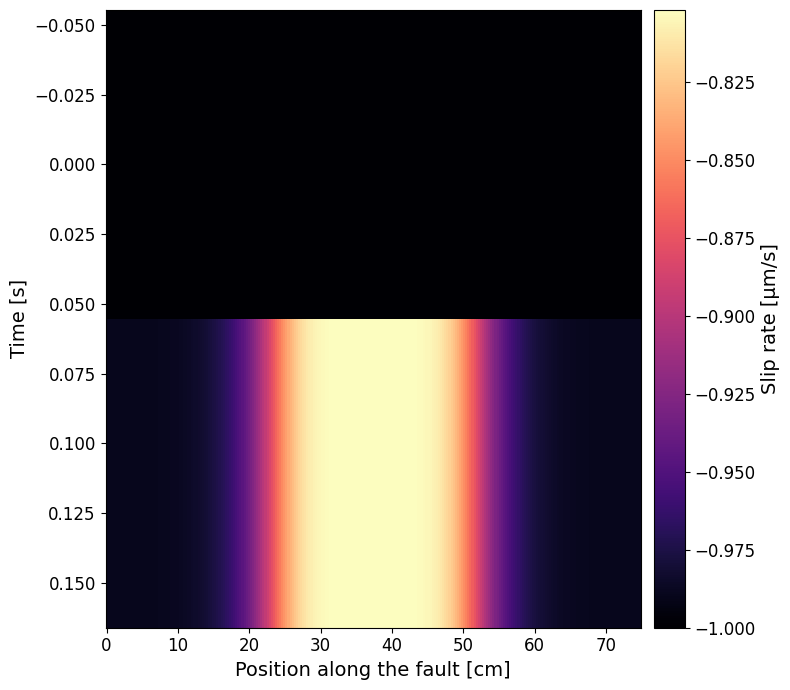

  → Evento 001: t=[0.0000, 0.2222]s salvato


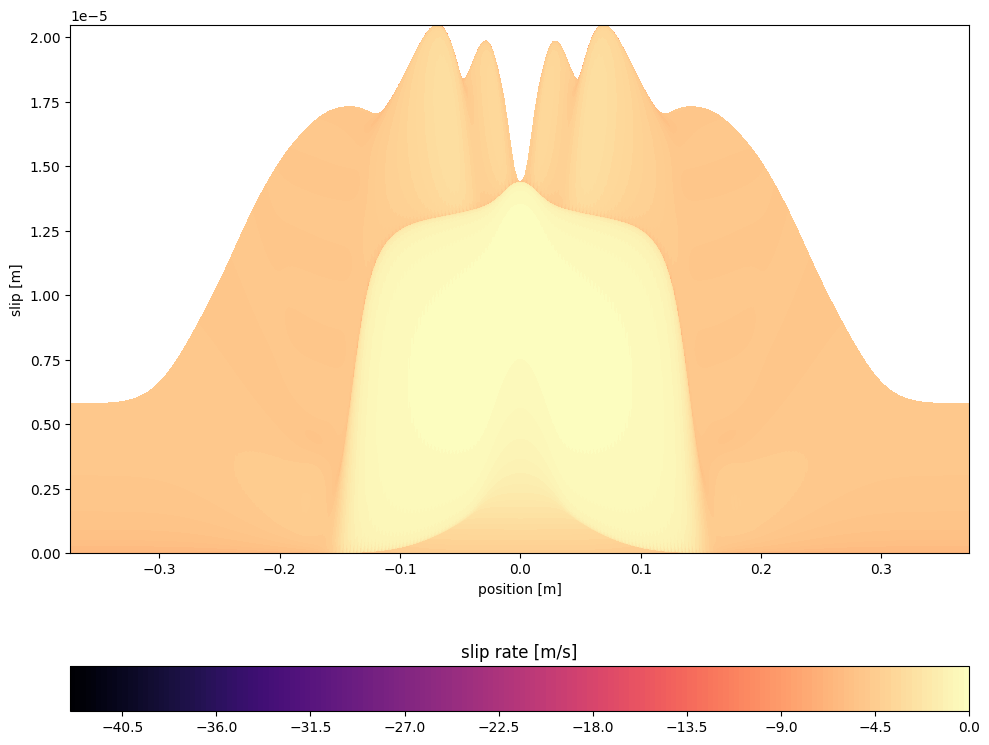

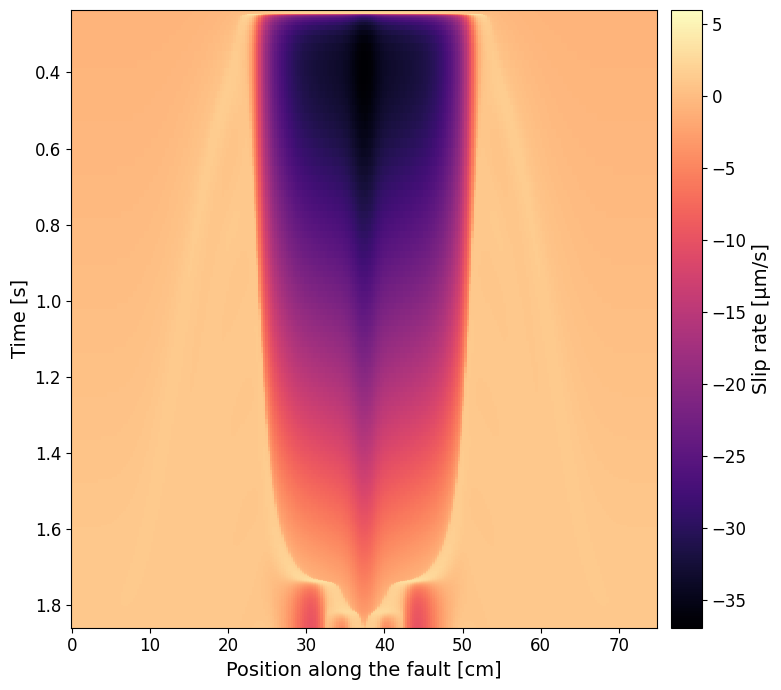

  → Evento 002: t=[0.2222, 1.8631]s salvato


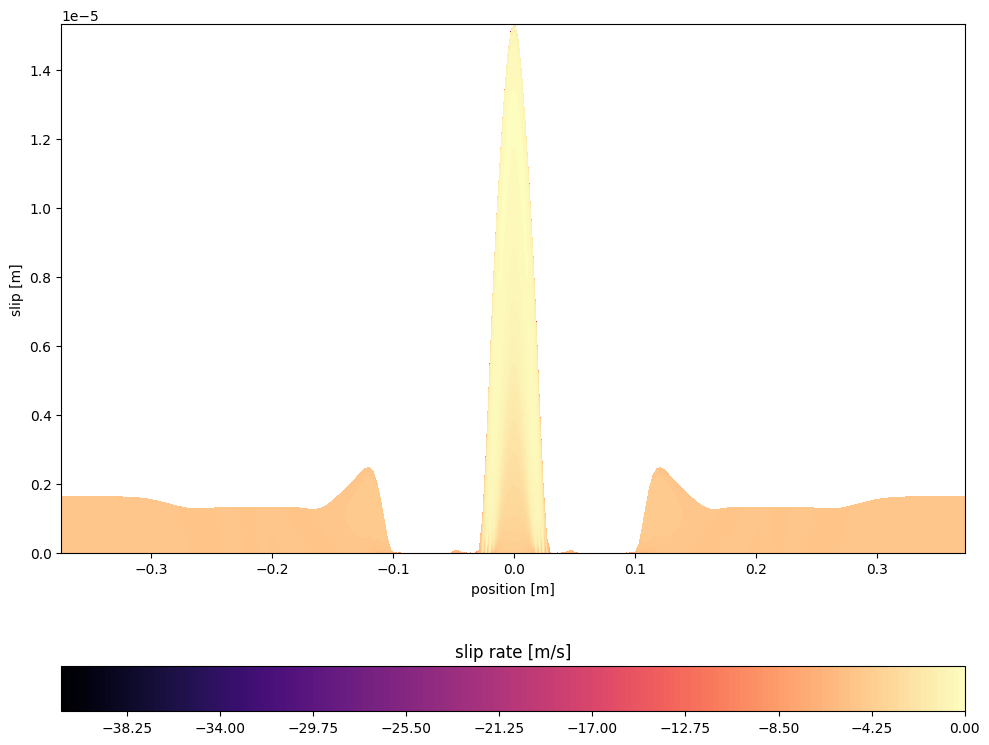

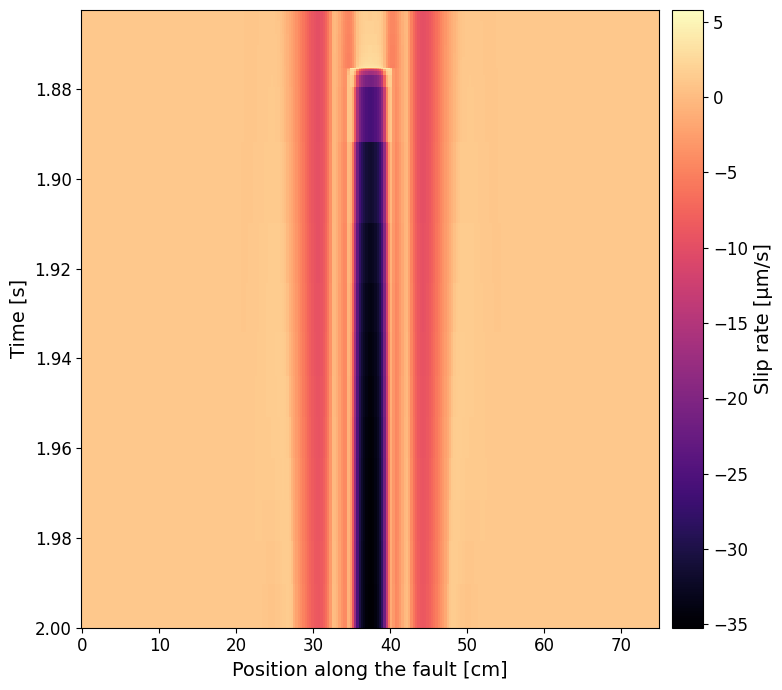

  → Evento 003: t=[1.8631, 2.0000]s salvato

✓ Simulazione 4 completata: 3 eventi salvati in 'Simulazione_4_20260519'


In [23]:
parametri(0.011, 1e-6, 20e6)

#sigma_n = 6e6
#dc_values = [15e-6, 5e-6, 1e-6]
#b_values = [0.012, 0.014]

---
#Lettura dati
---

In [24]:
#Ricerca evento
percorso_evento = "/content/drive/MyDrive/Tesi/Grafici/Simulazione_4_20260519/Evento_001/dati.npz"
dati = np.load(percorso_evento, allow_pickle=True)

#Metadati
meta = json.loads(str(dati['metadati']))
print("--- METADATI ---")
for chiave, valore in meta.items():
    print(f"  {chiave}: {valore}")

#DataFrame
ot_ricostruito = pd.DataFrame({
    't'    : dati['ot_t'],
    'tau'  : dati['ot_tau'],
    'theta': dati['ot_theta'],
    'sigma': dati['ot_sigma'],
})

ot_vmax_ricostruito = pd.DataFrame({
    't': dati['ot_vmax_t'],
    'v': dati['ot_vmax_v'],
})

ox_ricostruito = pd.DataFrame({
    'x'   : dati['ox_x'],
    't'   : dati['ox_t'],
    'v'   : dati['ox_v'],
    'slip': dati['ox_slip'],
})

print(f"\n--- DATI ---")
print(f"  Intervallo temporale: {dati['ot_t'].min():.4f} → {dati['ot_t'].max():.4f} s")
print(f"  Velocità massima: {dati['ot_vmax_v'].max():.3e} m/s")
print(f"  Campioni ot: {len(dati['ot_t'])}")
print(f"  Campioni ox: {len(dati['ox_t'])}")

--- METADATI ---
  simulazione_n: 4
  evento_n: 1
  data: 20260519
  tmin_s: 0.0
  tmax_s: 0.22223399373121
  b: 0.011
  Dc_m: 1e-06
  sigma_n_Pa: 20000000.0
  TMAX: 2
  V_PL: 1e-05
  MU: 2000000000.0
  N: 512
  L: 0.75

--- DATI ---
  Intervallo temporale: 0.0000 → 0.2222 s
  Velocità massima: 9.670e-06 m/s
  Campioni ot: 12
  Campioni ox: 768


---
# Synthetic generation
---

For the moment we can take values from
https://pubs.geoscienceworld.org/gsa/geology/article/45/8/731/207628/Evolution-of-shear-fabric-in-granular-fault-gouge

**Parameter Selection and Rationale**

To explore the transition of fault slip modes using QDYN, we need to define our rate-and-state friction (RSF) parameters based on the microstructural evolution described in the paper:

* **Normal Stress ($\sigma_n$)**: We will start with a normal stress of 3 MPa, and **we might investigate from 3 to 10 MPa**. Please note that while the experiments in the paper were conducted at normal stresses ranging from 13 MPa to 35 MPa, testing at lower normal stresses is a great way to observe how they affect the critical rheologic stiffness and instability nucleation.
* **Critical Slip Distance ($D_c$)**: The study shows that $D_c$ decreases drastically with accumulated shear strain. It starts around 15 µm (representing the initial average grain size) and reduces to 1 µm or sub-micrometric values as deformation localizes into continuous Y-shears. We will sweep from 1 µm to 15 µm.
* **Friction Rate Parameter ($(a-b)$)**: To ensure we only explore velocity-weakening conditions (a necessary condition for stick-slip instability), we must ensure $(a-b) < 0$. The paper documents $(a-b)$ reaching values down to approximately -0.0025 at high strains. In the script, we will hold the direct effect parameter ($a$) constant at 0.010 and sweep the evolution effect parameter ($b$) through values greater than $a$ (e.g., 0.011, 0.012, and 0.013).

**Some ideas at the beginning**

* **Test for Stick-Slip:** Start with these initial values to see if you can trigger fault instabilities (i.e., stick-slip behavior).
* **Plot a Stability Map:** A great next step would be to plot a stability map, identifying regions in the $(a-b)$, $D_c$, and normal stress ($\sigma_n$) parameter space that produce stable versus unstable sliding regimes.
* **Test a Homogeneous Fault:** You might also try removing the velocity-strengthening regions entirely, applying homogeneous velocity-weakening (negative $a-b$) along the whole fault.
